# 30.1 · Instance IDs versus class labels

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain instance ids versus class labels using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[27 · Object Detection](../../27-object-detection/README.md), [29 · Object Segmentation](../../29-object-segmentation/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Instance segmentation gives each object its own mask, even when objects share a class. Semantic segmentation alone labels all same-class pixels alike. Separating touching objects therefore requires additional structure, such as markers, proposals or object queries.

## 2. Intuition

An instance map stores a distinct ID for every object and usually reserves zero for background. IDs are local identifiers, not semantic categories. Two touching circles should have two instances even though both are foreground. Evaluation must match predicted and true instances before scoring overlap.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 30
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
D(p)=\min_{q\in background}\lVert p-q\rVert_2
$$

D(p) is a foreground pixel’s distance to background. For point p=[2,2] and background point q=[2,0], the distance is 2 pixels. Large local distances often occur near object interiors.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
p = np.array([2.0, 2.0])
q = np.array([2.0, 0.0])
distance = np.linalg.norm(p - q)
assert distance == 2
print(distance)

2.0


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The lab computes a foreground mask, distance map, marker labels and watershed boundaries. Counted instances are measured from the resulting IDs, not assumed from the input design.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def instances(lesson, seed, amount):
    mask = np.zeros((96, 112), np.uint8)
    cv2.circle(mask, (42, 48), 22, 255, -1)
    cv2.circle(mask, (72, 48), 22, 255, -1)
    distance = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    centers = (distance > distance.max() * 0.75).astype(np.uint8)
    _, markers = cv2.connectedComponents(centers)
    markers = markers + 1
    markers[(mask > 0) & (centers == 0)] = 0
    rgb = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    labels = cv2.watershed(rgb, markers.astype(np.int32))
    binary_labels, count = n.components(mask > 0)
    return Result(
        "30 · Semantic foreground versus separate instances",
        {
            "Merged foreground": mask,
            "Distance map": distance,
            "Seed components": centers,
            "Watershed instances": labels,
        },
        metrics={
            "binary_connected_objects": count,
            "watershed_foreground_instances": len([v for v in np.unique(labels) if v > 1]),
        },
        notes="Watershed is a classical instance baseline. Mask R-CNN inference is an optional pretrained workflow, not simulated by watershed.",
    )

{
  "binary_connected_objects": 1,
  "watershed_foreground_instances": 1
}
Watershed is a classical instance baseline. Mask R-CNN inference is an optional pretrained workflow, not simulated by watershed.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import components

display(Code(inspect.getsource(components), language="python"))

def components(mask):
    """4-connected foreground labels using a queue flood-fill, background=0."""
    mask = np.asarray(mask, bool)
    labels = np.zeros(mask.shape, np.int32)
    count = 0
    for y, x in zip(*np.nonzero(mask), strict=True):
        if labels[y, x]:
            continue
        count += 1
        labels[y, x] = count
        queue = deque([(y, x)])
        while queue:
            yy, xx = queue.popleft()
            for dy, dx in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                yn, xn = yy + dy, xx + dx
                if 0 <= yn < mask.shape[0] and 0 <= xn < mask.shape[1]:
                    if mask[yn, xn] and not labels[yn, xn]:
                        labels[yn, xn] = count
                        queue.append((yn, xn))
    return labels, count

## 8. Experiment

Move the two circles closer and vary the marker threshold. Identify the point at which seeds merge.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "binary_connected_objects": 1,
    "watershed_foreground_instances": 1
  },
  "second_seed": {
    "binary_connected_objects": 1,
    "watershed_foreground_instances": 1
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

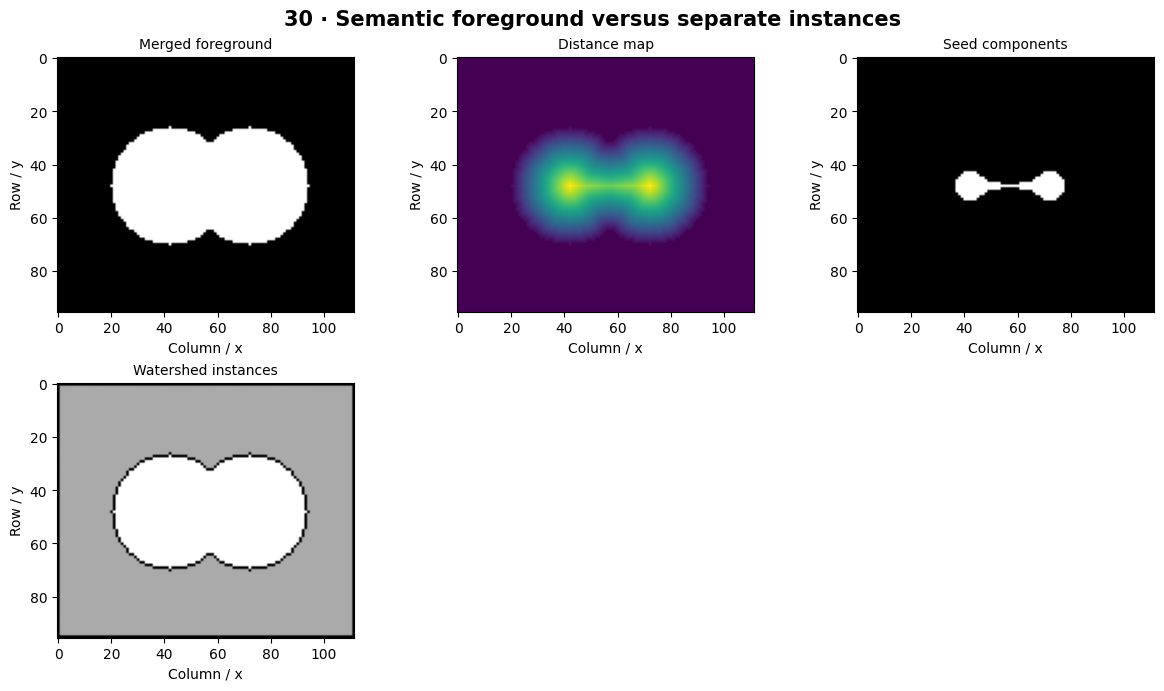

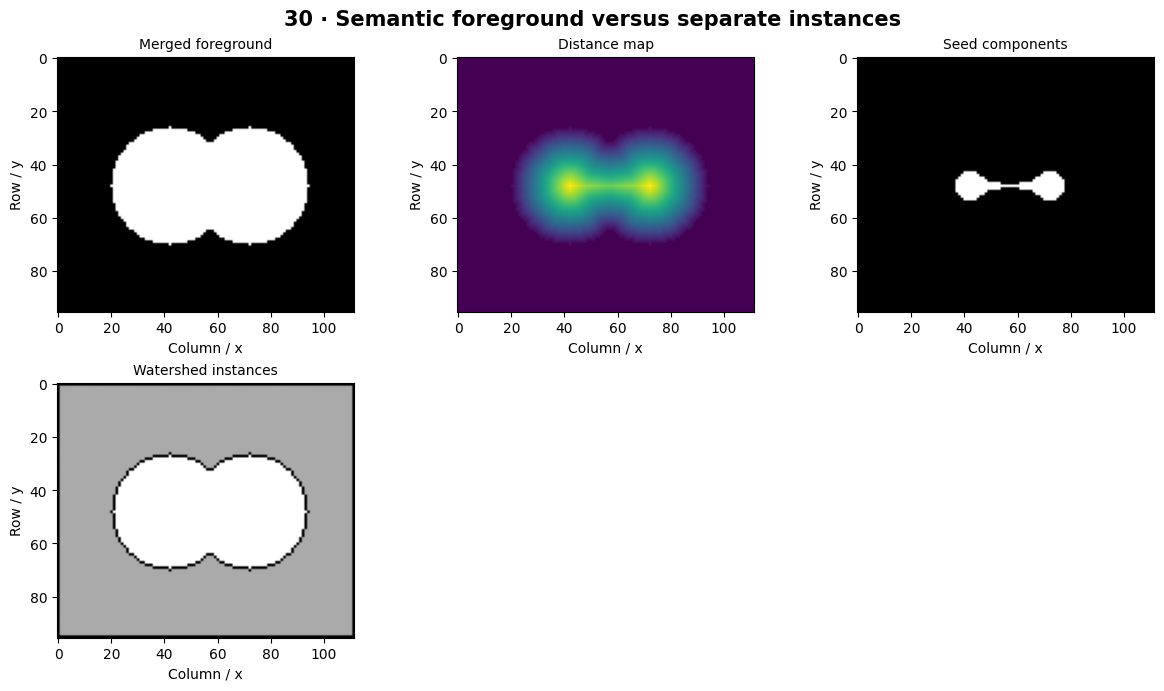

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Instance Counting System**. Keep object identity when masks overlap. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

A separate ID for every connected component fails when objects touch. Instance IDs are not stable track IDs across frames.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Move the two circles closer and vary the marker threshold. Identify the point at which seeds merge.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Create a touching-parts counter with automatic marker selection and an instance-matching evaluation.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

An instance map stores a distinct ID for every object and usually reserves zero for background. IDs are local identifiers, not semantic categories. Two touching circles should have two instances even though both are foreground. Evaluation must match predicted and true instances before scoring overlap.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Distance transforms and watershed** in this chapter.

[Primary reference](https://arxiv.org/abs/1703.06870) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)